<a href="https://colab.research.google.com/github/Froznrobt/sudo-proxy/blob/dev/14varthini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/brain stroke'
IMG_SIZE = (224, 224)
BATCH = 16
SEED = 42

Mounted at /content/drive


Mounted at /content/drive
Dataset folder found: /content/drive/MyDrive/brain stroke 
Normal -> 10 files
Stroke -> 30 files
label
Stroke    30
Normal    10
Name: count, dtype: int64


,file,label,width,height,path
0,a31.png,Normal,512,512,/content/drive/MyDrive/brain stroke /Normal/a3...
1,a32.png,Normal,512,512,/content/drive/MyDrive/brain stroke /Normal/a3...
2,a33.png,Normal,512,512,/content/drive/MyDrive/brain stroke /Normal/a3...
3,a34.png,Normal,512,512,/content/drive/MyDrive/brain stroke /Normal/a3...
4,a35.png,Normal,512,512,/content/drive/MyDrive/brain stroke /Normal/a3...


Found 40 files belonging to 2 classes.
Using 32 files for training.
Found 40 files belonging to 2 classes.
Using 8 files for validation.
Classes: ['Normal', 'Stroke']
Class weights: {0: 1.7777777777777777, 1: 0.6956521739130435}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.2812 - loss: 0.8723 - val_accuracy: 0.0000e+00 - val_loss: 1.1370
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5000 - loss: 0.7601 - val_accuracy: 0.5000 - val_loss: 0.7961
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5312 - loss: 0.7027 - val_accuracy: 0.6250 - val_loss: 0.6773
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5625 - loss: 0.9449 - val_accuracy: 0.6250 - val_loss: 0.6536
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6875 - loss: 0.6676 - val_accuracy: 0.6250 - val_loss: 0.6984
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6562 - loss: 0.6138 - val_accuracy: 0.500

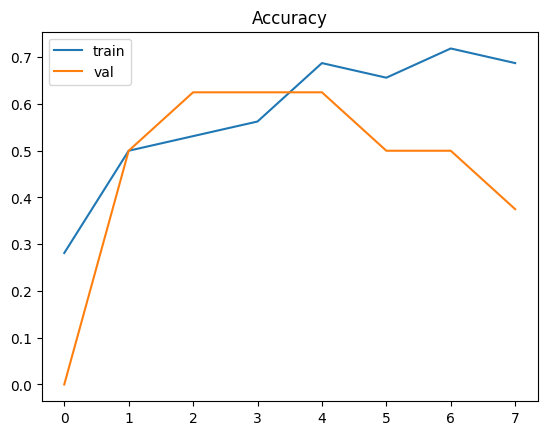

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
      Stroke       1.00      0.62      0.77         8

    accuracy                           0.62         8
   macro avg       0.50      0.31      0.38         8
weighted avg       1.00      0.62      0.77         8



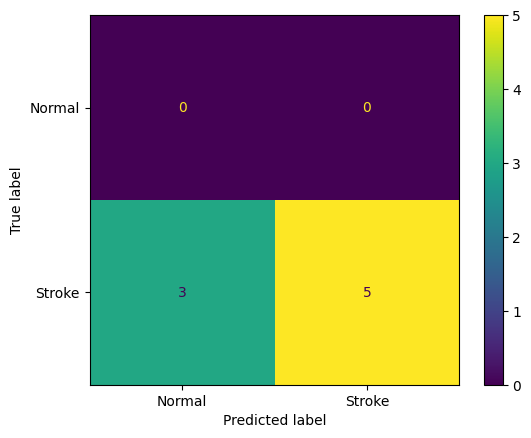

Saving a39.png to a39.png


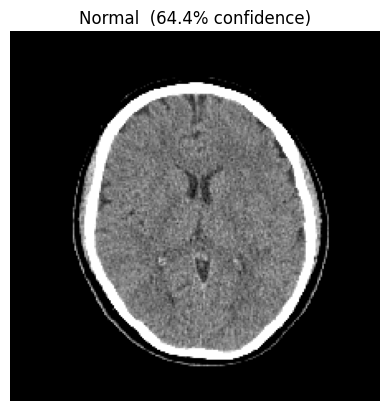

Prediction: Normal | Confidence: 64.41%


In [ ]:
# ============================================================
# EXPT 3 (v2): Normal vs Stroke brain image classifier (Google Colab)
# Paste each "CELL" section into its own Colab cell, or run all in one cell.
# Educational use only, not a diagnostic tool.
# ============================================================

# ---------------- CELL 1: Mount Drive and AUTO-FIND the dataset folder ----------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

IMG_SIZE = (224, 224)
BATCH = 16
SEED = 42

def find_dataset_dir(root='/content/drive'):
    """Finds the folder holding a1.png (unsorted) or Normal/Stroke subfolders (sorted)."""
    for dirpath, dirnames, filenames in os.walk(root):
        # skip Trash and hidden system folders
        if '/.Trash' in dirpath or '/.shortcut-targets-by-id' in dirpath and False:
            continue
        if 'a1.png' in [f.lower() for f in filenames]:
            return dirpath
        if 'Normal' in dirnames and 'Stroke' in dirnames:
            return dirpath
    return None

DATA_DIR = find_dataset_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find your images anywhere in Drive.\n"
        "1) Check that a1.png exists in your Drive.\n"
        "2) If the folder is under 'Shared with me', right-click it > Organize > Add shortcut,\n"
        "   then rerun this cell.")
print('Dataset folder found:', DATA_DIR)

# ---------------- CELL 2: Auto-organise images into class folders ----------------
# a1-a30  -> Stroke
# a31-a40 -> Normal  (assumed; change the label below if this is wrong)
# Safe to rerun: already-sorted images are left alone.
import re, shutil

for f in os.listdir(DATA_DIR):
    src = os.path.join(DATA_DIR, f)
    if not os.path.isfile(src):
        continue
    m = re.match(r'^a(\d+)\.(png|jpg|jpeg|bmp)$', f.lower())
    if not m:
        print('Skipped (name not matched):', f)
        continue
    n = int(m.group(1))
    if 1 <= n <= 30:
        label = 'Stroke'
    elif 31 <= n <= 40:
        label = 'Normal'
    else:
        print('Skipped (outside a1-a40):', f)
        continue
    os.makedirs(os.path.join(DATA_DIR, label), exist_ok=True)
    shutil.move(src, os.path.join(DATA_DIR, label, f))

for d in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, d)
    if os.path.isdir(p):
        print(d, '->', len(os.listdir(p)), 'files')

# ---------------- CELL 3: Imaging record catalogue (metadata retrieval) ----------------
import pandas as pd
from PIL import Image

records = []
for label in sorted(os.listdir(DATA_DIR)):
    folder = os.path.join(DATA_DIR, label)
    if not os.path.isdir(folder):
        continue
    for f in os.listdir(folder):
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            p = os.path.join(folder, f)
            try:
                w, h = Image.open(p).size
                records.append({'file': f, 'label': label, 'width': w, 'height': h, 'path': p})
            except Exception:
                print('Skipping corrupt file:', p)

df = pd.DataFrame(records)
print(df['label'].value_counts())
display(df.head())

# ---------------- CELL 4: Preprocess and split ----------------
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, label_mode='binary')

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, label_mode='binary', shuffle=False)

class_names = train_ds.class_names
print('Classes:', class_names)   # index 0 = Normal, index 1 = Stroke

# ---------------- CELL 5: Class weights (handles 30 vs 10 imbalance) ----------------
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.concatenate([y.numpy() for _, y in train_ds]).ravel().astype(int)
present = np.unique(train_labels)
w = compute_class_weight('balanced', classes=present, y=train_labels)
class_weight = {int(c): float(wt) for c, wt in zip(present, w)}
print('Class weights:', class_weight)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ---------------- CELL 6: Build and train the model ----------------
from tensorflow.keras import layers, models

augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,),
                                         include_top=False, weights='imagenet')
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = augment(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])

cb = [tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)]
history = model.fit(train_ds, validation_data=val_ds, epochs=15,
                    callbacks=cb, class_weight=class_weight)

model.save('/content/drive/MyDrive/stroke_model.keras')   # reuse later without retraining

# ---------------- CELL 7: Evaluate ----------------
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.title('Accuracy'); plt.show()

y_true = np.concatenate([y.numpy() for _, y in val_ds]).ravel().astype(int)
y_pred = (model.predict(val_ds).ravel() > 0.5).astype(int)

print(classification_report(y_true, y_pred, labels=[0, 1],
                            target_names=class_names, zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, labels=[0, 1]),
                       display_labels=class_names).plot()
plt.show()

# ---------------- CELL 8: Test with your own image ----------------
from google.colab import files
from tensorflow.keras.preprocessing import image

def predict_image(path):
    img = image.load_img(path, target_size=IMG_SIZE)
    arr = np.expand_dims(image.img_to_array(img), 0)
    prob = float(model.predict(arr, verbose=0)[0][0])
    idx = int(prob > 0.5)
    conf = prob if idx == 1 else 1 - prob
    plt.imshow(img); plt.axis('off')
    plt.title(f'{class_names[idx]}  ({conf*100:.1f}% confidence)')
    plt.show()
    print(f'Prediction: {class_names[idx]} | Confidence: {conf*100:.2f}%')

uploaded = files.upload()          # choose your test image
for name in uploaded:
    predict_image(name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder: /content/drive/MyDrive/dicom files
ubnormal    14
normal       9
Total DICOM files: 23
Enter DICOM file name (e.g. 10024 or 10024.dcm): 10000

===== 10000.dcm   (folder: normal) =====


,Field,Value
0,Patient Name,Not available
1,Patient ID,Not available
2,Birth Date,Not available
3,Sex,Not available
4,Age,Not available
5,Weight (kg),Not available
6,Study Date,Not available
7,Study Description,Not available
8,Series Description,Not available
9,Modality,Not available


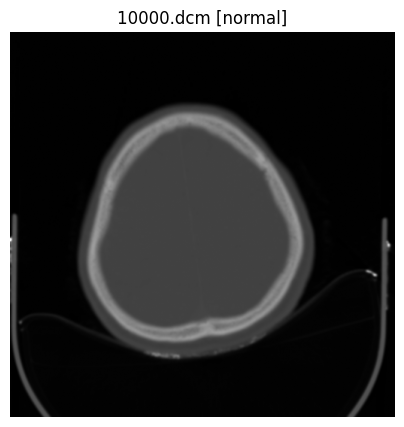

23 records


,Patient Name,Patient ID,Birth Date,Sex,Age,Weight (kg),Study Date,Study Description,Series Description,Modality,Body Part,Institution,Referring Physician,Manufacturer,Model,Rows,Columns,Folder,File
0,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10011.dcm
1,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10005.dcm
2,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10009.dcm
3,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10004.dcm
4,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10008.dcm
5,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10000.dcm
6,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10006.dcm
7,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10001.dcm
8,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,512,512,normal,10010.dcm
9,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,Not available,562,512,ubnormal,10062.dcm


In [ ]:
# ============================================================
# DICOM lookup (v2): searches the subfolders normal / ubnormal
# Type a file name (e.g. 10024) and get patient details + image + which folder it is in.
# Educational use only. Avoid sharing real patient data.
# ============================================================

# ---------------- CELL 1: Install, mount Drive, find the folder and all files ----------------
!pip install -q pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

from google.colab import drive
drive.mount('/content/drive')

import os, pydicom
import pandas as pd
import matplotlib.pyplot as plt

def find_dicom_dir(root='/content/drive/MyDrive'):
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath).strip().lower() == 'dicom files':
            return dirpath
    return None

DICOM_DIR = find_dicom_dir()
if DICOM_DIR is None:
    raise FileNotFoundError("Folder 'dicom files' not found in My Drive.")

# Walk through ALL subfolders (normal, ubnormal, ...) and record each .dcm file
dcm_index = []   # list of (group_folder, file_name, full_path)
for dirpath, _, filenames in os.walk(DICOM_DIR):
    group = os.path.relpath(dirpath, DICOM_DIR)
    group = 'root' if group == '.' else group
    for f in filenames:
        if f.lower().endswith('.dcm'):
            dcm_index.append((group, f, os.path.join(dirpath, f)))

print('Folder:', DICOM_DIR)
print(pd.Series([g for g, _, _ in dcm_index]).value_counts().to_string())
print('Total DICOM files:', len(dcm_index))

# ---------------- CELL 2: Helper functions ----------------
FIELDS = [
    ('Patient Name', 'PatientName'), ('Patient ID', 'PatientID'),
    ('Birth Date', 'PatientBirthDate'), ('Sex', 'PatientSex'),
    ('Age', 'PatientAge'), ('Weight (kg)', 'PatientWeight'),
    ('Study Date', 'StudyDate'), ('Study Description', 'StudyDescription'),
    ('Series Description', 'SeriesDescription'), ('Modality', 'Modality'),
    ('Body Part', 'BodyPartExamined'), ('Institution', 'InstitutionName'),
    ('Referring Physician', 'ReferringPhysicianName'),
    ('Manufacturer', 'Manufacturer'), ('Model', 'ManufacturerModelName'),
    ('Rows', 'Rows'), ('Columns', 'Columns'),
]

def fmt_date(v):
    v = str(v)
    return f'{v[0:4]}-{v[4:6]}-{v[6:8]}' if len(v) == 8 and v.isdigit() else v

def get_details(ds):
    rows = []
    for label, tag in FIELDS:
        val = getattr(ds, tag, None)
        if val is None or str(val).strip() == '':
            val = 'Not available'
        elif tag in ('PatientBirthDate', 'StudyDate'):
            val = fmt_date(val)
        else:
            val = str(val).replace('^', ' ')
        rows.append((label, val))
    return pd.DataFrame(rows, columns=['Field', 'Value'])

def show_image(ds, title=''):
    try:
        arr = ds.pixel_array.astype(float)
    except Exception as e:
        print('Could not decode pixel data:', e)
        return
    if arr.ndim == 3 and arr.shape[-1] not in (3, 4):   # multi-frame: middle frame
        arr = arr[arr.shape[0] // 2]
    arr = arr * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        arr = arr.max() - arr
    plt.figure(figsize=(5, 5))
    plt.imshow(arr, cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

def lookup(name):
    name = name.strip()
    if not name.lower().endswith('.dcm'):
        name += '.dcm'
    hits = [t for t in dcm_index if t[1].lower() == name.lower()]
    if not hits:   # partial match, e.g. "10017" also finds "10017 (1).dcm"
        stem = name[:-4].lower()
        hits = [t for t in dcm_index if t[1].lower().startswith(stem)]
    if not hits:
        print('No file matches:', name)
        return
    for group, f, path in hits:
        ds = pydicom.dcmread(path, force=True)
        print(f'\n===== {f}   (folder: {group}) =====')
        display(get_details(ds))
        show_image(ds, title=f'{f} [{group}]')

# ---------------- CELL 3: Enter a file name -> patient details ----------------
user_input = input('Enter DICOM file name (e.g. 10024 or 10024.dcm): ')
lookup(user_input)

# ---------------- CELL 4 (optional): Table of ALL files with their folder, saved as CSV ----------------
rows = []
for group, f, path in dcm_index:
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)
    except Exception:
        continue
    d = dict(get_details(ds).values)
    d['Folder'] = group
    d['File'] = f
    rows.append(d)

cat_df = pd.DataFrame(rows)
print(len(cat_df), 'records')
display(cat_df.head(10))
cat_df.to_csv('/content/drive/MyDrive/dicom_catalogue.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder: /content/drive/MyDrive/dicom files
ubnormal    14
normal       9
Total DICOM files: 23


Saving 10011.dcm to 10011.dcm

===== 10011.dcm =====
--- Patient / study details ---


,Field,Value
0,Patient Name,Not available
1,Patient ID,Not available
2,Birth Date,Not available
3,Sex,Not available
4,Age,Not available
5,Weight (kg),Not available
6,Study Date,Not available
7,Study Description,Not available
8,Series Description,Not available
9,Modality,Not available


--- All header fields present in this file ---


,Tag,Name,Value
0,"(0008,0016)",SOP Class UID,1.2.840.10008.5.1.4.1.1.2
1,"(0018,0050)",Slice Thickness,1.250000
2,"(0028,0002)",Samples per Pixel,1
3,"(0028,0004)",Photometric Interpretation,MONOCHROME2
4,"(0028,0010)",Rows,512
5,"(0028,0011)",Columns,512
6,"(0028,0030)",Pixel Spacing,"[0.439453, 0.439453]"
7,"(0028,0100)",Bits Allocated,16
8,"(0028,0101)",Bits Stored,16
9,"(0028,0102)",High Bit,15


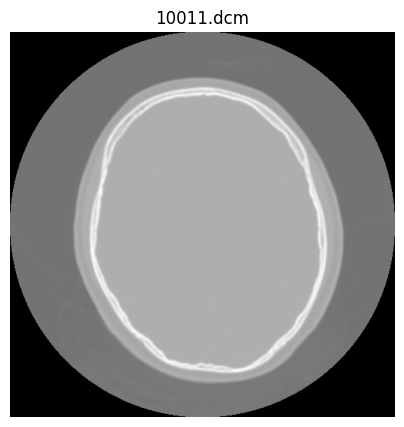

In [ ]:
# ============================================================
# DICOM patient details (v3): two ways to input a DICOM file
#   3A) Upload a .dcm file from your computer
#   3B) Type a file name from your Drive folder (normal / ubnormal)
# Educational use only. Avoid sharing real patient data.
# ============================================================

# ---------------- CELL 1: Install, mount Drive, index the Drive folder ----------------
!pip install -q pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

from google.colab import drive, files
drive.mount('/content/drive')

import os, pydicom
import pandas as pd
import matplotlib.pyplot as plt

def find_dicom_dir(root='/content/drive/MyDrive'):
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath).strip().lower() == 'dicom files':
            return dirpath
    return None

DICOM_DIR = find_dicom_dir()
dcm_index = []   # (group_folder, file_name, full_path)
if DICOM_DIR is None:
    print("Folder 'dicom files' not found. Option 3A (upload) still works.")
else:
    for dirpath, _, filenames in os.walk(DICOM_DIR):
        group = os.path.relpath(dirpath, DICOM_DIR)
        group = 'root' if group == '.' else group
        for f in filenames:
            if f.lower().endswith('.dcm'):
                dcm_index.append((group, f, os.path.join(dirpath, f)))
    print('Folder:', DICOM_DIR)
    print(pd.Series([g for g, _, _ in dcm_index]).value_counts().to_string())
    print('Total DICOM files:', len(dcm_index))

# ---------------- CELL 2: Helper functions ----------------
FIELDS = [
    ('Patient Name', 'PatientName'), ('Patient ID', 'PatientID'),
    ('Birth Date', 'PatientBirthDate'), ('Sex', 'PatientSex'),
    ('Age', 'PatientAge'), ('Weight (kg)', 'PatientWeight'),
    ('Study Date', 'StudyDate'), ('Study Description', 'StudyDescription'),
    ('Series Description', 'SeriesDescription'), ('Modality', 'Modality'),
    ('Body Part', 'BodyPartExamined'), ('Institution', 'InstitutionName'),
    ('Referring Physician', 'ReferringPhysicianName'),
    ('Manufacturer', 'Manufacturer'), ('Model', 'ManufacturerModelName'),
    ('Rows', 'Rows'), ('Columns', 'Columns'),
]

def fmt_date(v):
    v = str(v)
    return f'{v[0:4]}-{v[4:6]}-{v[6:8]}' if len(v) == 8 and v.isdigit() else v

def get_details(ds):
    rows = []
    for label, tag in FIELDS:
        val = getattr(ds, tag, None)
        if val is None or str(val).strip() == '':
            val = 'Not available'
        elif tag in ('PatientBirthDate', 'StudyDate'):
            val = fmt_date(val)
        else:
            val = str(val).replace('^', ' ')
        rows.append((label, val))
    return pd.DataFrame(rows, columns=['Field', 'Value'])

def get_all_fields(ds):
    """Every header field that really exists in the file (skips raw pixel data)."""
    rows = []
    for elem in ds:
        if elem.tag == (0x7FE0, 0x0010):
            continue
        val = str(elem.value)
        rows.append((str(elem.tag), elem.name, val[:80]))
    return pd.DataFrame(rows, columns=['Tag', 'Name', 'Value'])

def show_image(ds, title=''):
    try:
        arr = ds.pixel_array.astype(float)
    except Exception as e:
        print('Could not decode pixel data:', e)
        return
    if arr.ndim == 3 and arr.shape[-1] not in (3, 4):   # multi-frame: middle frame
        arr = arr[arr.shape[0] // 2]
    arr = arr * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        arr = arr.max() - arr
    plt.figure(figsize=(5, 5))
    plt.imshow(arr, cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

def report(path, label):
    ds = pydicom.dcmread(path, force=True)
    print(f'\n===== {label} =====')
    print('--- Patient / study details ---')
    display(get_details(ds))
    print('--- All header fields present in this file ---')
    display(get_all_fields(ds))
    show_image(ds, title=label)

# ---------------- CELL 3A: INPUT OPTION 1 - upload a DICOM file from your computer ----------------
uploaded = files.upload()          # choose one or more .dcm files
for name in uploaded:
    report(name, name)

# ---------------- CELL 3B: INPUT OPTION 2 - type a file name from your Drive folder ----------------
def lookup(name):
    name = name.strip()
    if not name.lower().endswith('.dcm'):
        name += '.dcm'
    hits = [t for t in dcm_index if t[1].lower() == name.lower()]
    if not hits:   # partial match, e.g. "10017" also finds "10017 (1).dcm"
        stem = name[:-4].lower()
        hits = [t for t in dcm_index if t[1].lower().startswith(stem)]
    if not hits:
        print('No file matches:', name)
        return
    for group, f, path in hits:
        report(path, f'{f}  (folder: {group})')

user_input = input('Enter DICOM file name (e.g. 10024 or 10024.dcm): ')
lookup(user_input)

# ---------------- CELL 4 (optional): Table of ALL Drive files, saved as CSV ----------------
rows = []
for group, f, path in dcm_index:
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)
    except Exception:
        continue
    d = dict(get_details(ds).values)
    d['Folder'] = group
    d['File'] = f
    rows.append(d)

cat_df = pd.DataFrame(rows)
print(len(cat_df), 'records')
display(cat_df.head(10))
cat_df.to_csv('/content/drive/MyDrive/dicom_catalogue.csv', index=False)

In [ ]:
import os, pydicom
group, f, path = dcm_index[0]
with open(path, 'rb') as fh:
    head = fh.read(140)
print('File:', f, '| size:', os.path.getsize(path), 'bytes')
print('Valid DICOM marker (DICM):', head[128:132] == b'DICM')
ds = pydicom.dcmread(path, force=True)
print('Number of header elements:', len(ds))
print(ds)

File: 10011.dcm | size: 115538 bytes
Valid DICOM marker (DICM): True
Number of header elements: 18
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 212
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.278.3.3456765700.729.1551958889.809.64
(0002,0010) Transfer Syntax UID                 UI: JPEG 2000 Image Compression (Lossless Only)
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.30071.8
(0002,0013) Implementation Version Name         SH: 'fo-dicom 4.0.0'
(0002,0016) Source Application Entity Title     AE: 'TEKNOYPYZEKA'
-------------------------------------------------
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0018,0050) Slice Thickness                     DS: '1.250000'
(0028,0002) Samples per Pixel                   US: 1
(0028,0004) Ph

In [ ]:
valid = sum(open(p, 'rb').read(132)[128:132] == b'DICM' for _, _, p in dcm_index)
print(valid, 'of', len(dcm_index), 'files have a valid DICOM marker')

23 of 23 files have a valid DICOM marker


,Field,Value
0,Patient Name,CompressedSamples CT1
1,Patient ID,1CT1
2,Birth Date,Not available
3,Sex,O
4,Age,000Y
5,Weight (kg),0.000000
6,Study Date,2004-01-19
7,Study Description,e+1
8,Series Description,Not available
9,Modality,CT


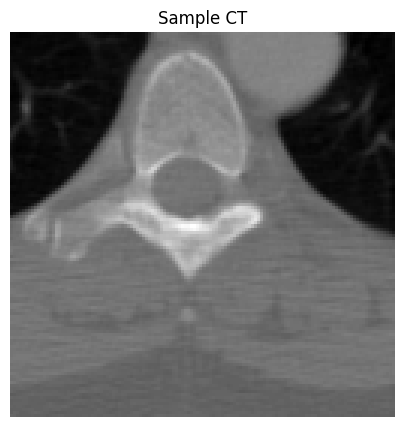

In [ ]:
from pydicom.data import get_testdata_file
ds = pydicom.dcmread(get_testdata_file("CT_small.dcm"))
display(get_details(ds))
show_image(ds, title='Sample CT')